In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # plotting

In [2]:
df_gfs = pd.read_csv('grib_vent/comp_gfs_0_25.2025-06-04T11-55-04Z.csv')
df_ecm = pd.read_csv('grib_vent/comp_ecmwf_0_25.2025-06-04T11-55-16Z.csv')

In [3]:
def prepare_dataframe(df):
  """
  Prépare le DataFrame en calculant la norme et la direction du vent,
  convertit la colonne 'valid_time' en datetime et supprime certaines colonnes.

  Args:
    df: Le DataFrame d'entrée.

  Returns:
    Le DataFrame préparé.
  """
  df['force'] = np.sqrt(df['u10']**2 + df['v10']**2)
  df['direction'] = np.degrees(np.arctan2(df['u10'], df['v10']))

  def get_cardinal_direction(degrees):
    if 337.5 <= degrees < 360 or 0 <= degrees < 22.5:
      return 'N'
    elif 22.5 <= degrees < 67.5:
      return 'NE'
    elif 67.5 <= degrees < 112.5:
      return 'E'
    elif 112.5 <= degrees < 157.5:
      return 'SE'
    elif 157.5 <= degrees < 202.5:
      return 'S'
    elif 202.5 <= degrees < 247.5:
      return 'SW'
    elif 247.5 <= degrees < 292.5:
      return 'W'
    elif 292.5 <= degrees < 337.5:
      return 'NW'
    else:
      return ''

  # Adjust degrees to be between 0 and 360
  df['direction'] = df['direction'] % 360
  df['direction_cardinal'] = df['direction'].apply(get_cardinal_direction)

  #df['valid_time'] = pd.to_datetime(df['valid_time'])

  #columns_to_drop = ['step', 'time', 'surface', 'heightAboveGround']
  #df = df.drop(columns=columns_to_drop, errors='ignore')

  # conversion en datetime
  df["date"] = pd.to_datetime(df["valid_time"])

  # date de référence
  ref = pd.Timestamp("2025-06-04 00:00:00")
  # différence en heures
  df["temps"] = (df["date"] - ref).dt.total_seconds() / 3600


  return df

In [4]:
df_gfs = prepare_dataframe(df_gfs)
df_ecm = prepare_dataframe(df_ecm)

In [5]:
def sum_of_squared_norm_differences(da, db, t):
  df1 = da[da['valid_time'] == t].iloc[:-25]
  df2 = db[db['valid_time'] == t]

  """
  Calcule la somme des carrés des différences des normes de vent entre deux DataFrames.

  Les DataFrames doivent avoir la même structure et contenir une colonne 'force'.

  Args:
    df1: Premier DataFrame.
    df2: Deuxième DataFrame.

  Returns:
    La somme des carrés des différences des normes.
    Retourne None si les DataFrames n'ont pas la même longueur ou si 'force' est absent.
  """
  if len(df1) != len(df2):
    print("Les DataFrames n'ont pas la même longueur.")
    return None
  if 'force' not in df1.columns or 'force' not in df2.columns:
    print("La colonne 'force' n'est pas présente dans les DataFrames.")
    return None

  # Assurez-vous que les DataFrames sont alignés de manière appropriée
  # Par exemple, si vous comparez des points géographiques, assurez-vous qu'ils correspondent.
  # Ici, on suppose qu'ils sont déjà alignés correctement par l'index.
  squared_differences = (df2['force'].reset_index(drop=True) - df1['force'].reset_index(drop=True))**2
  sum_of_squares = squared_differences.sum()

  return sum_of_squares * 100 / (len(df1['force']) * 40**2)

In [6]:
def sum_of_squared_direction_differences(da, db, t):
  df1 = da[da['valid_time'] == t].iloc[:-25]
  df2 = db[db['valid_time'] == t]

  """
  Calcule la somme des carrés des différences des directions de vent en degrés entre deux DataFrames.

  Les DataFrames doivent avoir la même structure et contenir une colonne 'direction'.

  Args:
    df1: Premier DataFrame.
    df2: Deuxième DataFrame.

  Returns:
    La somme des carrés des différences des directions.
    Retourne None si les DataFrames n'ont pas la même longueur ou si 'direction' est absent.
  """
  if len(df1) != len(df2):
    print("Les DataFrames n'ont pas la même longueur.")
    return None
  if 'direction' not in df1.columns or 'direction' not in df2.columns:
    print("La colonne 'direction' n'est pas présente dans les DataFrames.")
    return None

  # Assurez-vous que les DataFrames sont alignés de manière appropriée
  # Par exemple, si vous comparez des points géographiques, assurez-vous qu'ils correspondent.
  # Ici, on suppose qu'ils sont déjà alignés correctement par l'index.
  # Gérer la différence d'angle en tenant compte de la périodicité de 360 degrés
  diff_degrees = (df2['direction'].reset_index(drop=True) - df1['direction'].reset_index(drop=True)) % 360
  # Assurez-vous que la différence est entre -180 et 180 pour avoir le chemin le plus court
  diff_degrees = np.where(diff_degrees > 180, diff_degrees - 360, diff_degrees)

  squared_differences = diff_degrees**2
  sum_of_squares = squared_differences.sum()

  return sum_of_squares * 100 / (len(df1['direction']) * 180**2)


Les DataFrames n'ont pas la même longueur.


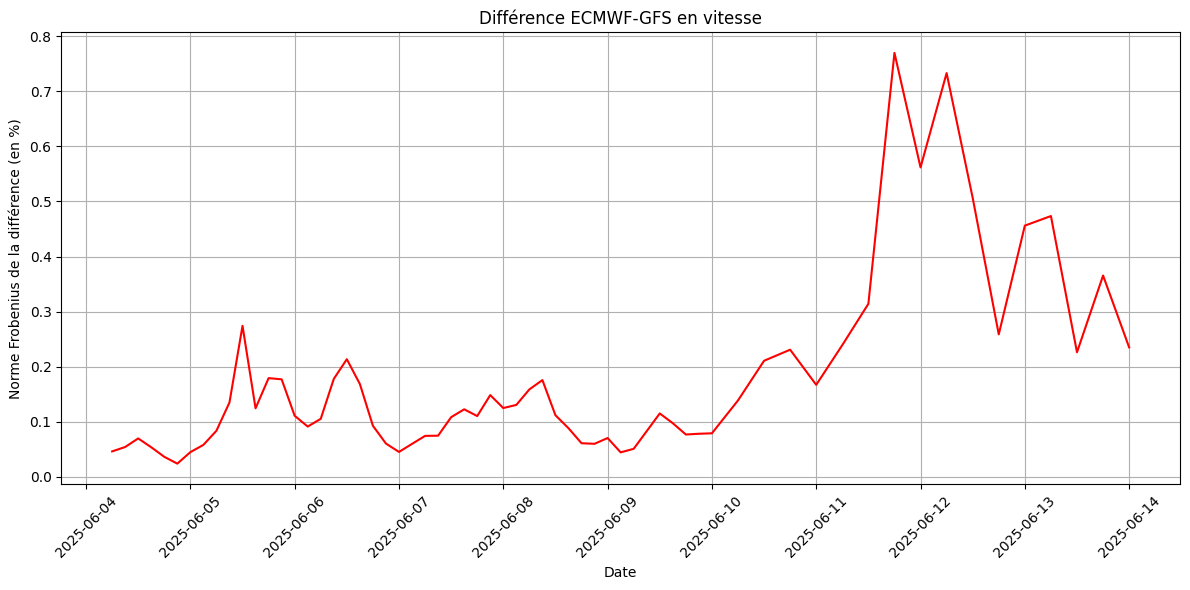

In [7]:
plt.figure(figsize=(12, 6))  # fig
plt.plot(pd.to_datetime(df_ecm['valid_time'].unique()), [sum_of_squared_norm_differences(df_ecm, df_gfs, t) for t in df_ecm['valid_time'].unique()], color = 'red')
plt.xlabel('Date')
plt.ylabel('Norme Frobenius de la différence (en %)')
plt.title('Différence ECMWF-GFS en vitesse')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Les DataFrames n'ont pas la même longueur.


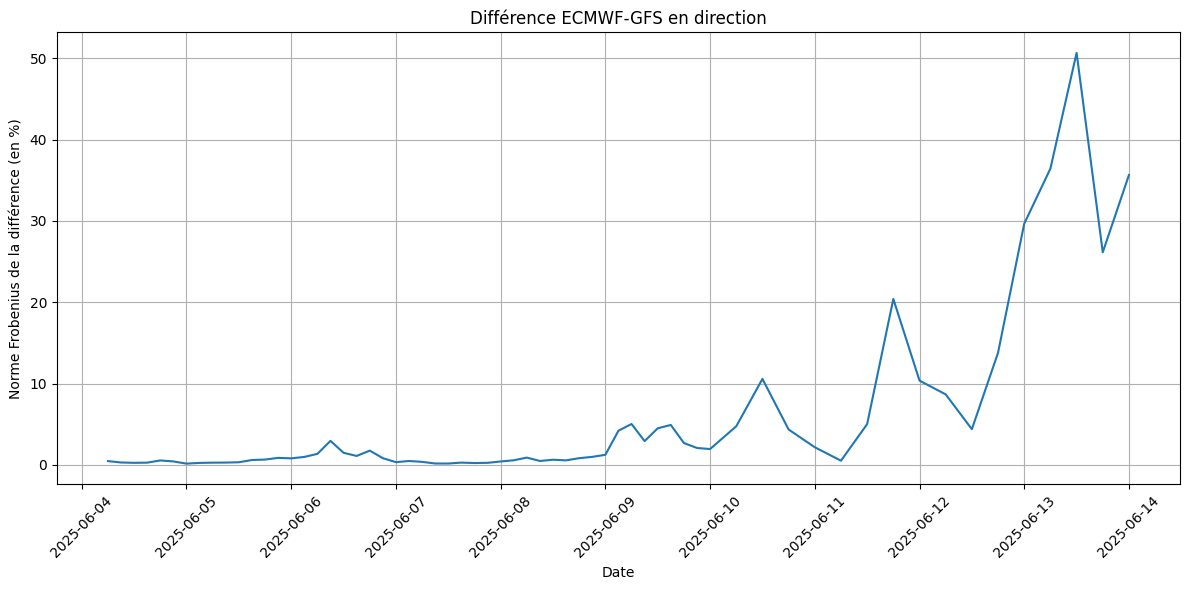

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(df_ecm['valid_time'].unique()), [sum_of_squared_direction_differences(df_ecm, df_gfs, t) for t in df_ecm['valid_time'].unique()])
plt.xlabel('Date')
plt.ylabel('Norme Frobenius de la différence (en %)')
plt.title('Différence ECMWF-GFS en direction')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
from scipy.interpolate import NearestNDInterpolator

In [10]:
df_gfs

,step,latitude,longitude,time,heightAboveGround,valid_time,u10,v10,force,direction,direction_cardinal,date,temps
0,0 days 00:00:00,45.25,0.25,2025-06-04 06:00:00,10.0,2025-06-04 06:00:00,7.55,-1.35,7.669746,100.137804,E,2025-06-04 06:00:00,6.0
1,0 days 00:00:00,45.25,354.25,2025-06-04 06:00:00,10.0,2025-06-04 06:00:00,7.00,-1.75,7.215435,104.036243,E,2025-06-04 06:00:00,6.0
2,0 days 00:00:00,45.25,354.50,2025-06-04 06:00:00,10.0,2025-06-04 06:00:00,7.30,-1.60,7.473286,102.362492,E,2025-06-04 06:00:00,6.0
3,0 days 00:00:00,45.25,354.75,2025-06-04 06:00:00,10.0,2025-06-04 06:00:00,7.70,-1.50,7.844743,101.023456,E,2025-06-04 06:00:00,6.0
4,0 days 00:00:00,45.25,355.00,2025-06-04 06:00:00,10.0,2025-06-04 06:00:00,7.80,-2.00,8.052329,104.381395,E,2025-06-04 06:00:00,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51595,16 days 00:00:00,49.00,359.00,2025-06-04 06:00:00,10.0,2025-06-20 06:00:00,-3.45,-2.00,3.987794,239.898693,SW,2025-06-20 06:00:00,390.0
51596,16 days 00:00:00,49.00,359.25,2025-06-04 06:00:00,10.0,2025-06-20 06:00:00,-2.15,-2.05,2.970690,226.363925,SW,2025-06-20 06:00:00,390.0
51597,16 days 00:00:00,49.00,359.50,2025-06-04 06:00:00,10.0,2025-06-20 06:00:00,-1.15,-2.20,2.482439,207.597293,SW,2025-06-20 06:00:00,390.0
51598,16 days 00:00:00,49.00,359.75,2025-06-04 06:00:00,10.0,2025-06-20 06:00:00,-2.10,-1.50,2.580698,234.462315,SW,2025-06-20 06:00:00,390.0


In [11]:
points_gfs = np.array(df_gfs[['longitude', 'latitude', 'temps']])
values_gfs = np.array(df_gfs[['direction', 'force']])
interp_func_gfs = NearestNDInterpolator(points_gfs, values_gfs)

def gfs(p, t):
    x, y = p[0], p[1]
    return interp_func_gfs(x, y, t)

In [12]:
points_ecm = np.array(df_ecm[['longitude', 'latitude', 'temps']])
values_ecm = np.array(df_ecm[['direction', 'force']])
interp_func_ecm = NearestNDInterpolator(points_ecm, values_ecm)

def ecm(p, t):
    x, y = p[0], p[1]
    return interp_func_ecm(x, y, t)

In [15]:
%matplotlib qt

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import timedelta

# -------------------------
# Vent affiché : GFS
# -------------------------
# `gfs(p, t)` doit être défini plus haut (cellule précédente).
# On l'enveloppe pour accepter l'argument `ref` utilisé plus bas.

def vent_gfs(p, t, ref="deg"):
    direction, speed = gfs(p, t)
    return float(direction), float(speed)

V = vent_gfs

# -------------------------
# Paramètres de la grille (depuis df_gfs)
# -------------------------
intx = [float(df_gfs["longitude"].min()), float(df_gfs["longitude"].max())]
inty = [float(df_gfs["latitude"].min()), float(df_gfs["latitude"].max())]
intt = [0, float(df_gfs["temps"].max())]

n = 50

# Retrouve la date de référence (celle utilisée pour `temps`)
first_valid = pd.to_datetime(df_gfs["valid_time"].iloc[0])
first_t = float(df_gfs["temps"].iloc[0])
start_date = first_valid - timedelta(hours=first_t)

lon = np.linspace(intx[0], intx[1], n + 1)
lat = np.linspace(inty[0], inty[1], n + 1)
X, Y = np.meshgrid(lon, lat)

# -------------------------
# Initialisation figure
# -------------------------
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.Mercator())
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.COASTLINE, linewidth=1)

gl = ax.gridlines(
    draw_labels=True,
    crs=ccrs.PlateCarree(),
    linestyle="--",
    alpha=0.6,
)
gl.top_labels = False
gl.right_labels = False

ax.set_extent([intx[0], intx[1], inty[0], inty[1]], crs=ccrs.PlateCarree())

# -------------------------
# Fonction pour calculer le vent
# -------------------------
def compute_wind(t):
    U = np.zeros_like(X, dtype=float)
    Vv = np.zeros_like(Y, dtype=float)
    C = np.zeros_like(X, dtype=float)

    for i in range(n + 1):
        for j in range(n + 1):
            direction, speed = V([X[i, j], Y[i, j]], t, ref="deg")
            U[i, j] = -speed * np.sin(np.radians(direction))
            Vv[i, j] = -speed * np.cos(np.radians(direction))
            C[i, j] = speed

    return U, Vv, C

# -------------------------
# Vent initial t=0
# -------------------------
initial_time = float(intt[0])
U, Vv, C = compute_wind(initial_time)
q = ax.quiver(X, Y, U, Vv, C, transform=ccrs.PlateCarree(), cmap="Greys")

# -------------------------
# (Optionnel) Route si disponible
# -------------------------
if all(name in globals() for name in ["latitude", "longitude", "L", "time_list"]):
    for i in range(len(latitude)):
        l = L[L[:, 2] == i]
        ax.plot(l[:, 1], l[:, 0], transform=ccrs.PlateCarree(), c="lightcoral")

    ax.plot(longitude, latitude, transform=ccrs.PlateCarree(), c="red")
    boat_scatter = ax.scatter(longitude[0], latitude[0], c="red", transform=ccrs.PlateCarree())
else:
    boat_scatter = None

# -------------------------
# Slider
# -------------------------
ax_slider = plt.axes([0.2, 0.02, 0.6, 0.03])
slider = Slider(
    ax_slider,
    "Temps",
    valmin=float(intt[0]),
    valmax=float(intt[1]),
    valinit=float(intt[0]),
    valstep=1,
    facecolor="grey",
)
slider.vline.set_visible(False)

initial_date = start_date + timedelta(hours=float(initial_time))
slider.valtext.set_text(initial_date.strftime("%d/%m %H:%M"))

def update(val):
    t = float(slider.val)
    U, Vv, C = compute_wind(t)
    q.set_UVC(U, Vv, C)

    current_date = start_date + timedelta(hours=t)
    slider.valtext.set_text(current_date.strftime("%d/%m %H:%M"))

    if boat_scatter is not None:
        idx = int(np.argmin(np.abs(np.asarray(time_list) - t)))
        boat_scatter.set_offsets([[longitude[idx], latitude[idx]]])

    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()


NameError: name 'VENT' is not defined